# 04 — Pretraining
Shows the training loop and loss curve on TinyShakespeare.

In [1]:
import torch, matplotlib.pyplot as plt

## Load and inspect the checkpoint

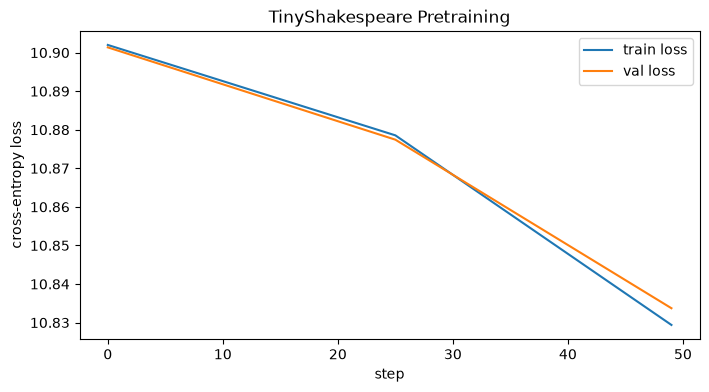

Final train loss: 10.8294
Final val   loss: 10.8337


In [2]:
ckpt = torch.load("../checkpoints/tiny_pretrain.pt", map_location="cpu", weights_only=False)
log  = ckpt["loss_log"]
steps = [e["step"] for e in log]
train_loss = [e["train"] for e in log]
val_loss   = [e["val"]   for e in log]

plt.figure(figsize=(8, 4))
plt.plot(steps, train_loss, label="train loss")
plt.plot(steps, val_loss,   label="val loss")
plt.xlabel("step"); plt.ylabel("cross-entropy loss"); plt.legend(); plt.title("TinyShakespeare Pretraining")
plt.savefig("../benchmarks/plots/pretrain_loss.png", dpi=120, bbox_inches="tight"); plt.show()
print(f"Final train loss: {train_loss[-1]:.4f}")
print(f"Final val   loss: {val_loss[-1]:.4f}")

## Generate text from the pretrained model

In [3]:
from model.config import TINY_CONFIG
from model.gpt import GPT
from inference.generate import generate_naive
import tiktoken
import sys; sys.path.insert(0, "..")

enc   = tiktoken.get_encoding("gpt2")
model = GPT(TINY_CONFIG)
model.load_state_dict(ckpt["model"])
model.eval()

prompt = enc.encode("To be or not to be")
out    = generate_naive(model, torch.tensor(prompt), max_new=50, temperature=0.8, top_k=40)
print(enc.decode(out.tolist()))

To be or not to beandom Woodsbullisa seizingued97rition dictatesandom protection Hik HikTAG tutorialuedFlickrJosephいCommerce Pureuras Query asymm civic dictates dictates373 floralTAGJosephchens effectsasuryandom Python electroly Woodsemphasisasury DjCrisa examinesemphasis HierJoseph�� lovers
